<a href="https://colab.research.google.com/github/isaacqsxsq/MNIST_Classifier/blob/main/MNIST_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torchvision.datasets as datasets
import torchvision.transforms.v2 as v2


In [ ]:
transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5])
])
train_val_dataset = datasets.MNIST(root='data', train=True, transform=transforms, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transforms, download=True)
train_dataset, val_dataset = random_split(train_val_dataset, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


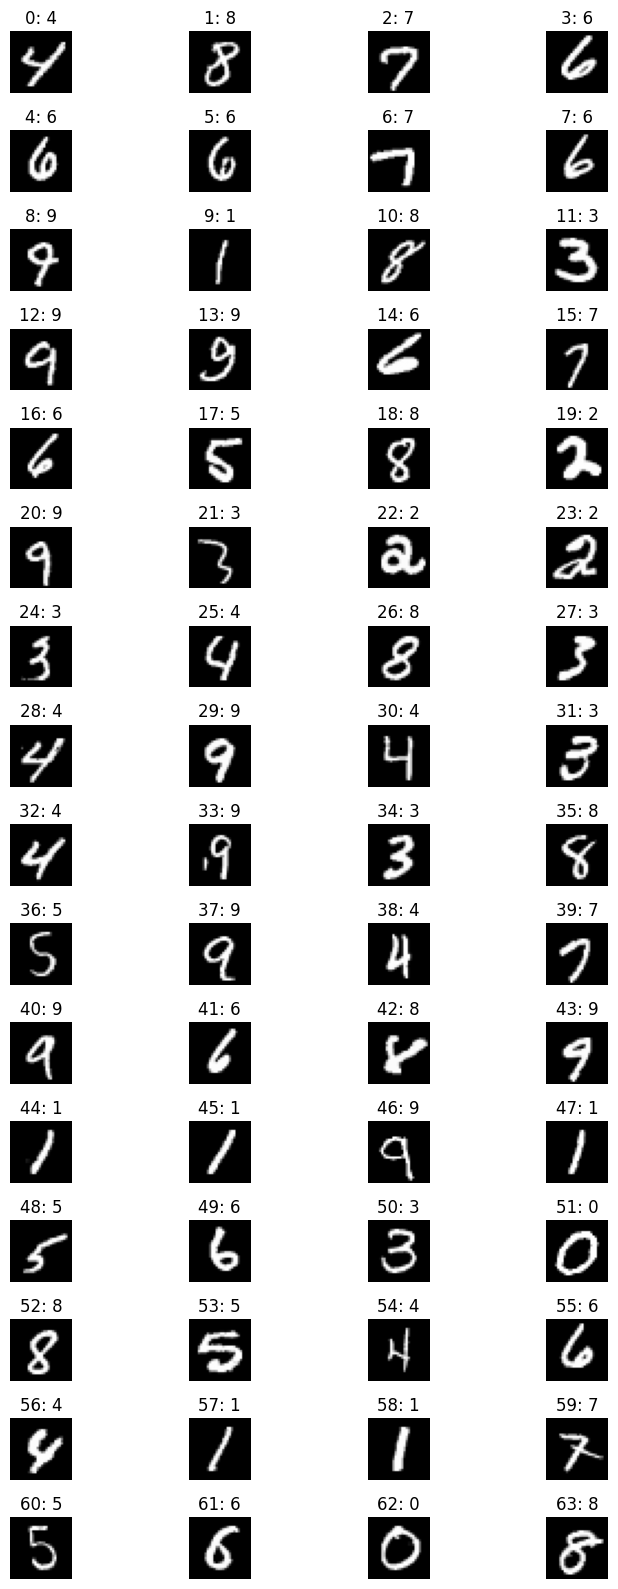

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=16, ncols=4, figsize=(8, 16))
for idx, (img, label) in enumerate(zip(images, labels)):
  img = img * 0.5 + 0.5
  axes.flat[idx].imshow(img.squeeze(), cmap='gray')
  axes.flat[idx].set_title(f'{idx}: {label.item()}')
  axes.flat[idx].axis('off')

plt.tight_layout()

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)
model.to('cuda')

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=3136, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [ ]:
%pip install torchmetrics

In [ ]:
import torchmetrics
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
acc = torchmetrics.Accuracy(task='multiclass', num_classes=10).to('cuda')

In [ ]:
train_losses, val_losses, val_accs = [], [], []
best_val = float('inf')
for epoch in range(10):
  model.train()
  r_loss = 0.0
  for images, labels in train_loader:
    images = images.to('cuda')
    labels = labels.to('cuda')
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    r_loss += loss.item()
  print(f'Epoch: {epoch+1}, Loss: {r_loss/len(train_loader)}')
  train_losses.append(r_loss/len(train_loader))
  model.eval()
  val_loss = 0.0
  acc.reset()
  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to('cuda'), labels.to('cuda')
      outputs = model(images)
      val_loss += criterion(outputs, labels).item()
      acc.update(outputs, labels)

  print(f'Validation Loss: {val_loss/len(val_loader)}, Accuracy: {acc.compute().item()}')
  val_losses.append(val_loss/len(val_loader))      # 저장
  val_accs.append(acc.compute().item())

  v = val_loss/len(val_loader)
  if v < best_val:
    best_val = v
    torch.save(model.state_dict(), 'best_model.pth')



Epoch: 1, Loss: 0.19341152955604066
Validation Loss: 0.06879486779795047, Accuracy: 0.9779999852180481
Epoch: 2, Loss: 0.05252065559637154
Validation Loss: 0.04556376735567098, Accuracy: 0.9848999977111816
Epoch: 3, Loss: 0.03559421662509482
Validation Loss: 0.043603919661503024, Accuracy: 0.9857000112533569
Epoch: 4, Loss: 0.028066343674559027
Validation Loss: 0.0382837585657746, Accuracy: 0.9878000020980835
Epoch: 5, Loss: 0.020911211781080186
Validation Loss: 0.036367086600586414, Accuracy: 0.9886000156402588
Epoch: 6, Loss: 0.015962915533548505
Validation Loss: 0.04220712404055996, Accuracy: 0.9872000217437744
Epoch: 7, Loss: 0.013343109152405738
Validation Loss: 0.03854211685675935, Accuracy: 0.9901999831199646
Epoch: 8, Loss: 0.011092586516889193
Validation Loss: 0.04634064252771568, Accuracy: 0.9871000051498413
Epoch: 9, Loss: 0.010111201928090252
Validation Loss: 0.03378680168188905, Accuracy: 0.9908000230789185
Epoch: 10, Loss: 0.008211260140085316
Validation Loss: 0.044250405

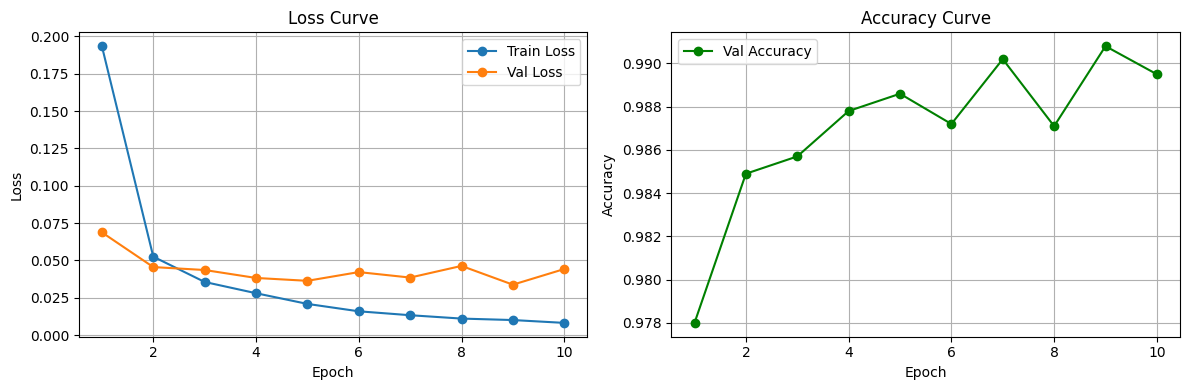

In [ ]:
epochs = range(1, len(train_losses)+1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: loss 곡선
ax1.plot(epochs, train_losses, 'o-', label='Train Loss')
ax1.plot(epochs, val_losses, 'o-', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

# 오른쪽: accuracy 곡선
ax2.plot(epochs, val_accs, 'o-', color='green', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

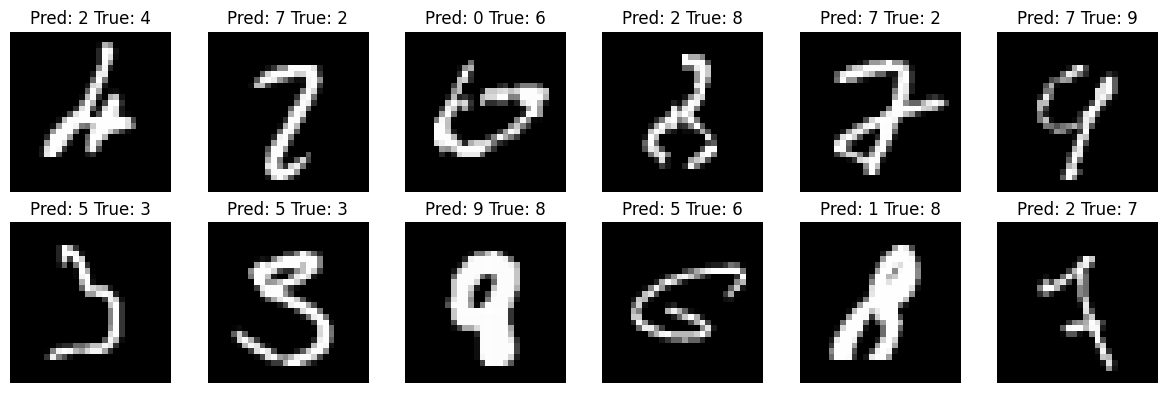

In [96]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
wrong_images, wrong_preds, wrong_labels = [], [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        preds = model(images).argmax(dim=1)
        mask = preds != labels
        wrong_images.extend(images[mask].cpu())
        wrong_preds.extend(preds[mask].cpu())
        wrong_labels.extend(labels[mask].cpu())

# Plot first 12 misclassified
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = wrong_images[i] * 0.5 + 0.5
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Pred: {wrong_preds[i]} True: {wrong_labels[i]}')
    ax.axis('off')
plt.tight_layout()